# Train a Deep NN to predict Asset Price returns

In practice, we need to explore variations of the design options outlined above because we can rarely be sure from the outset which network architecture best suits the data.

In this section, we will explore various options to build a simple feedforward Neural Network to predict asset price returns for a one-day horizon.

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%matplotlib inline

import os, sys
from ast import literal_eval as make_tuple
from time import time
from pathlib import Path
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
#sys.path.insert(1, os.path.join(sys.path[0], '..'))
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from utils import MultipleTimeSeriesCV, format_time

In [5]:
np.random.seed(42)
sns.set_style('whitegrid')
idx = pd.IndexSlice

In [6]:
DATA_STORE = '/home/sabateri/code/courses/machine-learning-for-trading/data/assets.h5'

In [7]:
results_path = Path('results')
if not results_path.exists():
    results_path.mkdir()
    
checkpoint_path = results_path / 'logs'

## Create a stock return series to predict asset price moves

To develop our trading strategy, we use the daily stock returns for some 995 US stocks for the eight year period from 2010 to 2017, and the features developed in Chapter 12 that include volatility and momentum factors as well as lagged returns with cross-sectional and sectoral rankings.

In [8]:
data = pd.read_hdf('./data.h5', 'model_data').dropna().sort_index()

In [9]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1881293 entries, ('A', Timestamp('2010-04-06 00:00:00')) to ('ZNGA', Timestamp('2017-11-29 00:00:00'))
Data columns (total 34 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   dollar_vol       1881293 non-null  float64
 1   dollar_vol_rank  1881293 non-null  float64
 2   rsi              1881293 non-null  float64
 3   bb_high          1881293 non-null  float64
 4   bb_low           1881293 non-null  float64
 5   NATR             1881293 non-null  float64
 6   ATR              1881293 non-null  float64
 7   PPO              1881293 non-null  float64
 8   MACD             1881293 non-null  float64
 9   sector           1881293 non-null  int64  
 10  r01              1881293 non-null  float64
 11  r05              1881293 non-null  float64
 12  r10              1881293 non-null  float64
 13  r21              1881293 non-null  float64
 14  r42              1881293 non-null  float6

In [10]:
outcomes = data.filter(like='fwd').columns.tolist()
outcomes

['r01_fwd', 'r05_fwd', 'r21_fwd']

In [11]:
lookahead = 1
outcome= f'r{lookahead:02}_fwd'

In [12]:
X_cv = data.loc[idx[:, :'2017'], :].drop(outcomes, axis=1)
y_cv = data.loc[idx[:, :'2017'], outcome]

In [13]:
y_cv

symbol  date      
A       2010-04-06   -0.007812
        2010-04-07   -0.008749
        2010-04-08    0.007061
        2010-04-09   -0.000584
        2010-04-12   -0.009062
                        ...   
ZNGA    2017-11-22    0.004926
        2017-11-24    0.022059
        2017-11-27    0.026379
        2017-11-28   -0.053738
        2017-11-29    0.012346
Name: r01_fwd, Length: 1881293, dtype: float64

In [14]:
len(X_cv.index.get_level_values('symbol').unique())

993

In [15]:
X_cv.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1881293 entries, ('A', Timestamp('2010-04-06 00:00:00')) to ('ZNGA', Timestamp('2017-11-29 00:00:00'))
Data columns (total 31 columns):
 #   Column           Dtype  
---  ------           -----  
 0   dollar_vol       float64
 1   dollar_vol_rank  float64
 2   rsi              float64
 3   bb_high          float64
 4   bb_low           float64
 5   NATR             float64
 6   ATR              float64
 7   PPO              float64
 8   MACD             float64
 9   sector           int64  
 10  r01              float64
 11  r05              float64
 12  r10              float64
 13  r21              float64
 14  r42              float64
 15  r63              float64
 16  r01dec           float64
 17  r05dec           float64
 18  r10dec           float64
 19  r21dec           float64
 20  r42dec           float64
 21  r63dec           float64
 22  r01q_sector      float64
 23  r05q_sector      float64
 24  r10q_sector      float64
 25 

## Automate model generation

The following `make_model` function illustrates how to flexibly define various architectural elements for the search process. The dense_layers argument defines both the depth and width of the network as a list of integers. We also use dropout for regularization, expressed as a float in the range [0, 1] to define the probability that a given unit will be excluded from a training iteration.

In [16]:
def make_model(dense_layers, activation, dropout, input_dim):
    """PyTorch equivalent of TensorFlow's make_model function
    
    Args:
        dense_layers: List/tuple of layer sizes
        activation: Activation function name ('relu', 'tanh', etc.)
        dropout: Dropout rate
        input_dim: Input dimension (number of features)
    
    Returns:
        model: PyTorch model
        criterion: Loss function
        optimizer: Optimizer
    """
    model = MLP(input_dim, dense_layers, activation, dropout)
    criterion = nn.MSELoss()  # mean squared error
    optimizer = optim.Adam(model.parameters())
    
    return model, criterion, optimizer

def train_epoch(model, criterion, optimizer, x_train, y_train, batch_size, shuffle=True):
    """Train for one epoch"""
    model.train()
    
    # Convert numpy arrays to PyTorch tensors
    x_tensor = torch.FloatTensor(x_train)
    y_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
    
    # Create dataset and dataloader
    dataset = TensorDataset(x_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    
    running_loss = 0.0
    for inputs, targets in dataloader:
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    return running_loss / len(dataset)

def predict(model, x_val):
    """Make predictions"""
    model.eval()
    with torch.no_grad():
        x_tensor = torch.FloatTensor(x_val)
        predictions = model(x_tensor).numpy()
    return predictions.squeeze()

## Cross-validate multiple configurations with TensorFlow

### Train-Test Split

We split the data into a training set for cross-validation, and keep the last 12 months with data as holdout test:

In [17]:
#n_splits = 12
#train_period_length=21 * 12 * 4
#test_period_length=21 * 3
n_splits = 12
train_period_length=21 * 12 * 4
test_period_length=21 * 3

In [18]:
cv = MultipleTimeSeriesCV(n_splits=n_splits,
                          train_period_length=train_period_length,
                          test_period_length=test_period_length,
                          lookahead=lookahead)

### Define CV Parameters

In [19]:
#dense_layer_opts = [(16, 8), (32, 16), (32, 32), (64, 32)]
dense_layer_opts = [(16, 8)]
#dense_layer_opts = [(2,2)]
#activation_opts = ['tanh']
activation_opts = ['relu']
#dropout_opts = [0, .1, .2]
dropout_opts = [0]

In [20]:
param_grid = list(product(dense_layer_opts, activation_opts, dropout_opts))
np.random.shuffle(param_grid)

In [21]:
len(param_grid)

1

To trigger the parameter search, we instantiate a GridSearchCV object, define the fit_params that will be passed to the Keras model’s fit method, and provide the training data to the GridSearchCV fit method:

In [22]:
def get_train_valid_data(X, y, train_idx, test_idx):
    x_train, y_train = X.iloc[train_idx, :], y.iloc[train_idx]
    x_val, y_val = X.iloc[test_idx, :], y.iloc[test_idx]
    return x_train, y_train, x_val, y_val



In [23]:

class MLP(nn.Module):
    def __init__(self, input_dim, dense_layers, activation, dropout):
        """Creates a multi-layer perceptron model
        
        Args:
            input_dim: Number of input features
            dense_layers: List/tuple of layer sizes; one number per layer
            activation: Activation function to use ('relu', 'tanh', etc.)
            dropout: Dropout rate before the final layer
        """
        super(MLP, self).__init__()
        
        # Map string activation to PyTorch function
        if activation == 'relu':
            activation_fn = nn.ReLU()
        elif activation == 'tanh':
            activation_fn = nn.Tanh()
        elif activation == 'sigmoid':
            activation_fn = nn.Sigmoid()
        else:
            activation_fn = nn.ReLU()  # Default
        
        # Build the layers
        layers = []
        prev_size = input_dim
        
        for i, layer_size in enumerate(dense_layers):
            layers.append(nn.Linear(prev_size, layer_size))
            layers.append(activation_fn)
            prev_size = layer_size
        
        # Add dropout before the final layer
        layers.append(nn.Dropout(dropout))
        
        # Add final output layer (for regression, no activation)
        layers.append(nn.Linear(prev_size, 1))
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)




In [24]:
do_training = True
if do_training:
    # For reproducibility
    torch.manual_seed(42)

    # Define your parameters
    checkpoint_path = Path("checkpoints")
    results_path = Path("results")
    if not results_path.exists():
        results_path.mkdir(parents=True)

    param_grid = list(product(dense_layer_opts, activation_opts, dropout_opts))
    np.random.shuffle(param_grid)

    ic = []
    scaler = StandardScaler()

    for params in param_grid:
        dense_layers, activation, dropout = params
        #for batch_size in [64, 256]:
        for batch_size in [256]:
            print(dense_layers, activation, dropout, batch_size)
            checkpoint_dir = checkpoint_path / str(dense_layers) / activation / str(dropout) / str(batch_size)
            if not checkpoint_dir.exists():
                checkpoint_dir.mkdir(parents=True, exist_ok=True)
            
            start = time()
            for fold, (train_idx, test_idx) in enumerate(cv.split(X_cv)):
                # get train & validation data
                x_train, y_train, x_val, y_val = get_train_valid_data(X_cv, y_cv, train_idx, test_idx)
                
                # scale features
                x_train = scaler.fit_transform(x_train)
                x_val = scaler.transform(x_val)
                
                # set up dataframes to log results
                preds = y_val.to_frame('actual')
                r = pd.DataFrame(index=y_val.groupby(level='date').size().index)
                
                # create model based on validation parameters
                model, criterion, optimizer = make_model(
                    dense_layers, 
                    activation, 
                    dropout, 
                    input_dim=x_train.shape[1]
                )
                
                # cross-validate for 10 epochs
                EPOCHS=10
                for epoch in range(EPOCHS):
                    # Train one epoch
                    train_epoch(
                        model, 
                        criterion, 
                        optimizer, 
                        x_train, 
                        y_train, 
                        batch_size=batch_size, 
                        shuffle=True
                    )
                    
                    # Save model weights
                    torch.save(
                        model.state_dict(), 
                        checkpoint_dir / f'ckpt_{fold}_{epoch}.pt'
                    )
                    
                    # Make predictions
                    preds[epoch] = predict(model, x_val)
                    
                    # Calculate metrics
                    r[epoch] = preds.groupby(level='date').apply(
                        lambda x: spearmanr(x.actual, x[epoch])[0]
                    ).to_frame(epoch)
                    
                    print(format_time(time()-start), 
                            f'{fold + 1:02d} | {epoch + 1:02d} | {r[epoch].mean():7.4f} | {r[epoch].median():7.4f}')
                
                ic.append(r.assign(
                    dense_layers=str(dense_layers), 
                    activation=activation, 
                    dropout=dropout,
                    batch_size=batch_size,
                    fold=fold
                ))
            
            t = time()-start
            pd.concat(ic).to_hdf(results_path / 'scores.h5', 'ic_by_day')

(16, 8) relu 0 256
00:00:10 01 | 01 |  0.0051 |  0.0009
00:00:18 01 | 02 |  0.0125 |  0.0014
00:00:25 01 | 03 |  0.0218 |  0.0251
00:00:31 01 | 04 |  0.0199 |  0.0148
00:00:38 01 | 05 |  0.0086 |  0.0048
00:00:46 01 | 06 |  0.0129 |  0.0171
00:00:53 01 | 07 |  0.0060 |  0.0115
00:00:59 01 | 08 |  0.0166 |  0.0277
00:01:07 01 | 09 |  0.0232 |  0.0265
00:01:14 01 | 10 |  0.0139 |  0.0215
00:01:22 02 | 01 | -0.0044 | -0.0028
00:01:30 02 | 02 |  0.0022 |  0.0107
00:01:36 02 | 03 |  0.0091 |  0.0119
00:01:43 02 | 04 |  0.0027 |  0.0022
00:01:52 02 | 05 | -0.0005 |  0.0090
00:01:60 02 | 06 | -0.0069 |  0.0066
00:02:06 02 | 07 | -0.0014 | -0.0027
00:02:13 02 | 08 |  0.0038 |  0.0248
00:02:21 02 | 09 | -0.0002 | -0.0050
00:02:28 02 | 10 | -0.0025 | -0.0025
00:02:35 03 | 01 |  0.0051 |  0.0107
00:02:43 03 | 02 |  0.0167 |  0.0124
00:02:51 03 | 03 | -0.0145 | -0.0292
00:02:59 03 | 04 | -0.0021 | -0.0237
00:03:05 03 | 05 |  0.0207 |  0.0222
00:03:13 03 | 06 |  0.0246 |  0.0230
00:03:20 03 | 07 | 

### Evaluate predictive performance

In [25]:
params = ['dense_layers', 'dropout', 'batch_size']

In [26]:
ic = pd.read_hdf(results_path / 'scores.h5', 'ic_by_day').drop('activation', axis=1)
ic.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2017-08-30 to 2015-03-02
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   0             756 non-null    float64
 1   1             756 non-null    float64
 2   2             756 non-null    float64
 3   3             756 non-null    float64
 4   4             756 non-null    float64
 5   5             756 non-null    float64
 6   6             756 non-null    float64
 7   7             756 non-null    float64
 8   8             756 non-null    float64
 9   9             756 non-null    float64
 10  dense_layers  756 non-null    object 
 11  dropout       756 non-null    int64  
 12  batch_size    756 non-null    int64  
 13  fold          756 non-null    int64  
dtypes: float64(10), int64(3), object(1)
memory usage: 88.6+ KB


In [27]:
ic.groupby(params).size()

dense_layers  dropout  batch_size
(16, 8)       0        256           756
dtype: int64

In [28]:
ic_long = pd.melt(ic, id_vars=params + ['fold'], var_name='epoch', value_name='ic')
ic_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   dense_layers  7560 non-null   object 
 1   dropout       7560 non-null   int64  
 2   batch_size    7560 non-null   int64  
 3   fold          7560 non-null   int64  
 4   epoch         7560 non-null   object 
 5   ic            7560 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 354.5+ KB


In [29]:
ic_long

,dense_layers,dropout,batch_size,fold,epoch,ic
0,"(16, 8)",0,256,0,0,-0.038617
1,"(16, 8)",0,256,0,0,0.049989
2,"(16, 8)",0,256,0,0,0.057366
3,"(16, 8)",0,256,0,0,0.029854
4,"(16, 8)",0,256,0,0,0.128867
...,...,...,...,...,...,...
7555,"(16, 8)",0,256,11,9,0.022591
7556,"(16, 8)",0,256,11,9,0.051258
7557,"(16, 8)",0,256,11,9,-0.089047
7558,"(16, 8)",0,256,11,9,-0.018394


In [30]:
ic_long = ic_long.groupby(params+ ['epoch', 'fold']).ic.mean().to_frame('ic').reset_index()

In [31]:
ic_long

,dense_layers,dropout,batch_size,epoch,fold,ic
0,"(16, 8)",0,256,0,0,0.005120
1,"(16, 8)",0,256,0,1,-0.004420
2,"(16, 8)",0,256,0,2,0.005091
3,"(16, 8)",0,256,0,3,0.000346
4,"(16, 8)",0,256,0,4,0.006519
...,...,...,...,...,...,...
115,"(16, 8)",0,256,9,7,0.024149
116,"(16, 8)",0,256,9,8,0.015172
117,"(16, 8)",0,256,9,9,0.006566
118,"(16, 8)",0,256,9,10,-0.000588


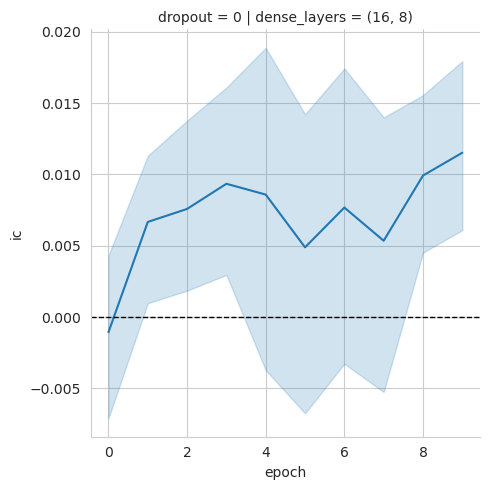

In [32]:
#g = sns.relplot(x='epoch', y='ic', col='dense_layers', row='dropout', 
#                data=ic_long[ic_long.dropout>0], kind='line')
g = sns.relplot(x='epoch', y='ic', col='dense_layers', row='dropout', 
                data=ic_long[ic_long.dropout>-1], kind='line')
g.map(plt.axhline, y=0, ls='--', c='k', lw=1)
g.savefig(results_path / 'ic_lineplot', dpi=300)

In [33]:
# def run_ols(ic):
#     ic.dense_layers = ic.dense_layers.str.replace(', ', '-').str.replace('(', '').str.replace(')', '')
#     data = pd.melt(ic, id_vars=params, var_name='epoch', value_name='ic')
#     data.epoch = data.epoch.astype(int).astype(str).apply(lambda x: f'{int(x):02.0f}')
#     model_data = pd.get_dummies(data.sort_values(params + ['epoch']), columns=['epoch'] + params, drop_first=True).sort_index(1)
#     model_data.columns = [s.split('_')[-1] for s in model_data.columns]
#     model = sm.OLS(endog=model_data.ic, exog=sm.add_constant(model_data.drop('ic', axis=1)))
#     return model.fit()

In [34]:
def run_ols(ic):
    ic.dense_layers = ic.dense_layers.str.replace(', ', '-').str.replace('(', '').str.replace(')', '')
    data = pd.melt(ic, id_vars=params, var_name='epoch', value_name='ic')
    data.epoch = data.epoch.astype(int).astype(str).apply(lambda x: f'{int(x):02.0f}')
    model_data = pd.get_dummies(data.sort_values(params + ['epoch']), columns=['epoch'] + params, drop_first=True, dtype = int).sort_index(axis=1)
    model_data.columns = [s.split('_')[-1] for s in model_data.columns]
    model_data = model_data.dropna() # there can be results from the fits with NaNs
    model = sm.OLS(endog=model_data.ic, exog=sm.add_constant(model_data.drop('ic', axis=1)))
    return model.fit()

In [35]:
# find the best model
model = run_ols(ic.drop('fold', axis=1))

In [36]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     ic   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6108
Date:                Wed, 23 Apr 2025   Prob (F-statistic):              0.789
Time:                        16:45:34   Log-Likelihood:                 5122.0
No. Observations:                7560   AIC:                        -1.022e+04
Df Residuals:                    7550   BIC:                        -1.015e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0011      0.004     -0.236      0.8

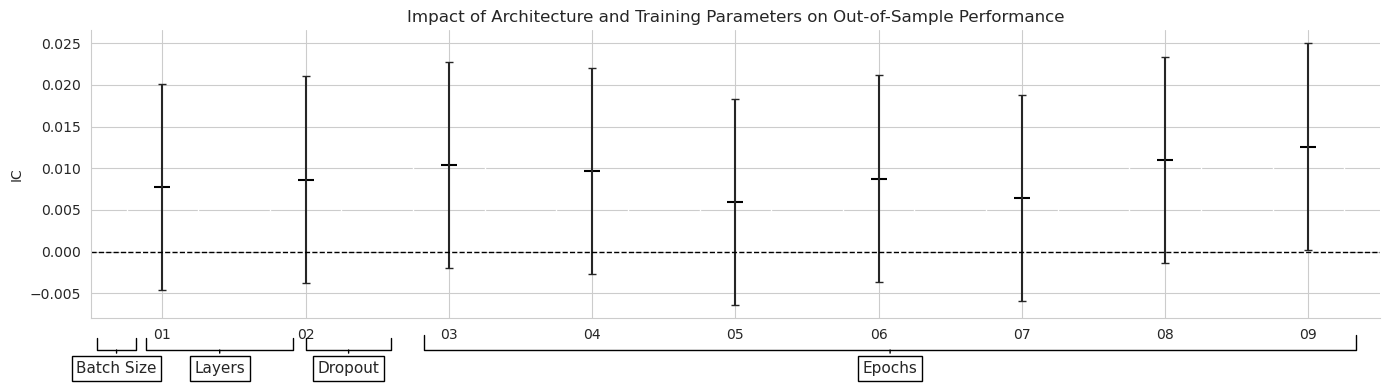

In [37]:
fig, ax = plt.subplots(figsize=(14, 4))

ci = model.conf_int()
errors = ci[1].sub(ci[0]).div(2)

coefs = (model.params.to_frame('coef').assign(error=errors)
         .reset_index().rename(columns={'index': 'variable'}))
coefs = coefs[~coefs['variable'].str.startswith('date') & (coefs.variable != 'const')]

coefs.plot(x='variable', y='coef', kind='bar',
           ax=ax, color='none', capsize=3,
           yerr='error', legend=False, rot=0, title='Impact of Architecture and Training Parameters on Out-of-Sample Performance')
ax.set_ylabel('IC')
ax.set_xlabel('')
#ax.scatter(x=pd.np.arange(len(coefs)), marker='_', s=120, y=coefs['coef'], color='black')
ax.scatter(x=np.arange(len(coefs)), marker='_', s=120, y=coefs['coef'], color='black')
ax.axhline(y=0, linestyle='--', color='black', linewidth=1)
ax.xaxis.set_ticks_position('none')

ax.annotate('Batch Size', xy=(.02, -0.1), xytext=(.02, -0.2),
            xycoords='axes fraction',
            textcoords='axes fraction',
            fontsize=11, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white', ec='black'),
            arrowprops=dict(arrowstyle='-[, widthB=1.3, lengthB=0.8', lw=1.0, color='black'))

ax.annotate('Layers', xy=(.1, -0.1), xytext=(.1, -0.2),
            xycoords='axes fraction',
            textcoords='axes fraction',
            fontsize=11, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white', ec='black'),
            arrowprops=dict(arrowstyle='-[, widthB=4.8, lengthB=0.8', lw=1.0, color='black'))

ax.annotate('Dropout', xy=(.2, -0.1), xytext=(.2, -0.2),
            xycoords='axes fraction',
            textcoords='axes fraction',
            fontsize=11, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white', ec='black'),
            arrowprops=dict(arrowstyle='-[, widthB=2.8, lengthB=0.8', lw=1.0, color='black'))

ax.annotate('Epochs', xy=(.62, -0.1), xytext=(.62, -0.2),
            xycoords='axes fraction',
            textcoords='axes fraction',
            fontsize=11, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white', ec='black'),
            arrowprops=dict(arrowstyle='-[, widthB=30.5, lengthB=1.0', lw=1.0, color='black'))

sns.despine()
fig.tight_layout()
fig.savefig(results_path / 'ols_coef', dpi=300)

## Make Predictions

In [38]:
def get_best_params(n=5):
    """Get the best parameters across all folds by daily median IC"""
    params = ['dense_layers', 'activation', 'dropout', 'batch_size']
    ic = pd.read_hdf(results_path / 'scores.h5', 'ic_by_day').drop('fold', axis=1)
    dates = sorted(ic.index.unique())
    train_period = 24 * 21
    train_dates = dates[:train_period]
    ic = ic.loc[train_dates]
    return (ic.groupby(params)
            .median()
            .stack()
            .to_frame('ic')
            .reset_index()
            .rename(columns={'level_4': 'epoch'})
            .nlargest(n=n, columns='ic')
            .drop('ic', axis=1)
            .to_dict('records'))

In [39]:
# def generate_predictions(dense_layers, activation, dropout, batch_size, epoch):
#     data = pd.read_hdf('/home/sabateri/code/courses/machine-learning-for-trading/12_gradient_boosting_machines/data.h5', 'model_data').dropna().sort_index()
#     outcomes = data.filter(like='fwd').columns.tolist()
#     X_cv = data.loc[idx[:, :'2017'], :].drop(outcomes, axis=1)
#     input_dim = X_cv.shape[1]
#     y_cv = data.loc[idx[:, :'2017'], 'r01_fwd']

#     scaler = StandardScaler()
#     predictions = []
    
#     do = '0' if str(dropout) == '0.0' else str(dropout)
#     checkpoint_dir = checkpoint_path / str(dense_layers) / activation / str(do) / str(batch_size)
        
#     for fold, (train_idx, test_idx) in enumerate(cv.split(X_cv)):
#         x_train, y_train, x_val, y_val = get_train_valid_data(X_cv, y_cv, train_idx, test_idx)
#         x_val = scaler.fit(x_train).transform(x_val)
#         model = make_model(make_tuple(dense_layers), activation, dropout)
#         status = model.load_weights((checkpoint_dir / f'ckpt_{fold}_{epoch}').as_posix())
#         status.expect_partial()
#         predictions.append(pd.Series(model.predict(x_val).squeeze(), index=y_val.index))
#     return pd.concat(predictions)        

In [40]:
def make_tuple(s):
    """Convert string representation of tuple to actual tuple"""
    if isinstance(s, tuple):
        return s
    # Remove parentheses and split by dash or comma
    if '-' in s:
        return tuple(int(x) for x in s.replace('(', '').replace(')', '').split('-'))
    else:
        return tuple(int(x) for x in s.replace('(', '').replace(')', '').split(','))

In [41]:
def generate_predictions(dense_layers, activation, dropout, batch_size, epoch, checkpoint_path):
    data = pd.read_hdf('./data.h5', 'model_data').dropna().sort_index()
    outcomes = data.filter(like='fwd').columns.tolist()
    X_cv = data.loc[idx[:, :'2017'], :].drop(outcomes, axis=1)
    input_dim = X_cv.shape[1]
    y_cv = data.loc[idx[:, :'2017'], 'r01_fwd']

    scaler = StandardScaler()
    predictions = []
    
    do = '0' if str(dropout) == '0.0' else str(dropout)
    checkpoint_dir = checkpoint_path / str(dense_layers) / activation / str(do) / str(batch_size)
        
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_cv)):
        x_train, y_train, x_val, y_val = get_train_valid_data(X_cv, y_cv, train_idx, test_idx)
        x_val = scaler.fit(x_train).transform(x_val)
        
        # Create the PyTorch model
        model, _, _ = make_model(
            make_tuple(dense_layers) if isinstance(dense_layers, str) else dense_layers, 
            activation, 
            dropout, 
            input_dim=x_train.shape[1]
        )
        
        # Load the saved PyTorch weights
        checkpoint_path = checkpoint_dir / f'ckpt_{fold}_{epoch}.pt'
        model.load_state_dict(torch.load(checkpoint_path))
        
        # Set model to evaluation mode
        model.eval()
        
        # Make predictions
        with torch.no_grad():
            x_tensor = torch.FloatTensor(x_val)
            preds = model(x_tensor).numpy().squeeze()
            
        predictions.append(pd.Series(preds, index=y_val.index))
        
    return pd.concat(predictions)

In [42]:
best_params = get_best_params()
predictions = []
checkpoint_path = Path("checkpoints")
for i, params in enumerate(best_params):
    predictions.append(generate_predictions(**params,checkpoint_path=checkpoint_path).to_frame(i))

predictions = pd.concat(predictions, axis=1)
print(predictions.info())
predictions.to_hdf(results_path / 'test_preds.h5', 'predictions')

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 746048 entries, ('A', Timestamp('2017-08-30 00:00:00')) to ('ZNGA', Timestamp('2015-03-02 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       746048 non-null  float32
 1   1       746048 non-null  float32
 2   2       746048 non-null  float32
 3   3       746048 non-null  float32
 4   4       746048 non-null  float32
dtypes: float32(5)
memory usage: 17.8+ MB
None


In [43]:
predictions.sort_index(level=1)

,,0,1,2,3,4
symbol,date,,,,,
A,2014-11-28,-0.000378,0.002957,0.002584,0.002171,0.003675
AAL,2014-11-28,-0.008393,-0.001053,0.008455,-0.003175,-0.001005
AAN,2014-11-28,0.001507,0.003322,0.005528,0.003455,0.005291
AAP,2014-11-28,-0.000019,0.002519,0.001175,0.002502,0.004554
AAPL,2014-11-28,-0.002411,-0.001232,0.003125,0.000672,0.005160
...,...,...,...,...,...,...
YUM,2017-11-29,-0.000086,-0.006762,-0.002546,-0.001229,-0.003084
ZBH,2017-11-29,-0.000723,-0.005806,-0.003236,-0.000509,-0.001450
ZBRA,2017-11-29,0.000668,-0.003833,-0.002152,0.000043,-0.001814


In [44]:
best_params

[{'dense_layers': '(16, 8)',
  'activation': 'relu',
  'dropout': 0,
  'batch_size': 256,
  'epoch': 4},
 {'dense_layers': '(16, 8)',
  'activation': 'relu',
  'dropout': 0,
  'batch_size': 256,
  'epoch': 9},
 {'dense_layers': '(16, 8)',
  'activation': 'relu',
  'dropout': 0,
  'batch_size': 256,
  'epoch': 2},
 {'dense_layers': '(16, 8)',
  'activation': 'relu',
  'dropout': 0,
  'batch_size': 256,
  'epoch': 5},
 {'dense_layers': '(16, 8)',
  'activation': 'relu',
  'dropout': 0,
  'batch_size': 256,
  'epoch': 6}]

### How to further improve the results

The relatively simple architecture yields some promising results. To further improve performance, you can
- First and foremost, add new features and more data to the model
- Expand the set of architectures to explore, including more or wider layers
- Inspect the training progress and train for more epochs if the validation error continued to improve at 50 epochs

Finally, you can use more sophisticated architectures, including Recurrent Neural Networks (RNN) and Convolutional Neural Networks that are well suited to sequential data, whereas vanilla feedforward NNs are not designed to capture the ordered nature of the features.
